# Final Project

## Import Relevant Libraries

$$\text{Percent Change} =  \frac{\text{Final Portfolio Value} - \text{Initial Portfolio Value}}{\text{Initial Portfolio Value}} * 100$$


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# ! pip install arch
# from arch import arch_model
from scipy.stats import norm, gaussian_kde, skew, kurtosis, mode
from scipy.ndimage import gaussian_filter1d

## Step 1: Simulate Market Returns with GARCH

In [ ]:
# Set randomization seed (optional)
# np.random.seed(100)

# Step 1: Simulate Market Returns with GARCH (Manual Implementation)
n_periods = 252  # Number of time steps

# Initial parameters
S0 = 100  # Initial stock price
T = 1     # 1-year maturity
dt = T / n_periods  # Time step
r = 0.05  # Risk-free rate
K = 100  # Strike price
num_calls = 1  # Number of call options held
shares_per_call = 1 # Number of shares tied to a single contract

# Constant volatility
def do_const_vol(n_periods, vol):
  returns = np.random.normal(loc=0, scale=vol * np.sqrt(1 / n_periods), size=n_periods)
  volatility = np.full(n_periods, vol)
  return returns, volatility

# GARCH
def do_garch(n_periods):
  # GARCH(1,1) Parameters
  omega = 0.1  # Long-term volatility component
  alpha = 0.1  # Impact of previous squared return
  beta = 0.8  # Impact of previous variance

  # Initialize arrays
  returns = np.zeros(n_periods)
  volatility = np.zeros(n_periods)
  volatility[0] = np.sqrt(omega / (1 - alpha - beta))  # Long-run variance

  # Simulate GARCH(1,1) process
  for t in range(1, n_periods):
      returns[t] = volatility[t - 1] * np.random.normal()
      volatility[t] = np.maximum(np.sqrt(omega + alpha * returns[t - 1]**2 + beta * volatility[t - 1]**2), 1e-6)

  return returns, volatility

def egarch(n_periods, returns):
  lmbda = 0.05  # Leverage effect term
  volatility = np.zeros(n_periods)
  volatility[0] = volatility[0]

  for t in range(1, n_periods):
      log_vol = np.log(volatility[t - 1]**2)
      shock = np.abs(returns[t - 1]) - np.sqrt(2 / np.pi)
      log_vol = omega + alpha * shock + beta * log_vol + lmbda * returns[t - 1]
      volatility[t] = np.exp(log_vol / 2)
  return volatility

# Simulate a sudden jump in volatility, like a market crash
def do_garch_with_shock(n_periods, shock_time=None, shock_factor=2.0):
  omega = 0.1
  alpha = 0.1
  beta = 0.8

  returns = np.zeros(n_periods)
  volatility = np.zeros(n_periods)
  volatility[0] = np.sqrt(omega / (1 - alpha - beta))

  # Set a shock at a random time if not specified
  if shock_time is None:
      shock_time = np.random.randint(n_periods // 2, n_periods)

  for t in range(1, n_periods):
      if t == shock_time:
          volatility[t - 1] *= shock_factor  # Apply shock

      returns[t] = volatility[t - 1] * np.random.normal()
      volatility[t] = np.maximum(np.sqrt(omega + alpha * returns[t - 1]**2 + beta * volatility[t - 1]**2), 1e-6)

  return returns, volatility

## Step 2: Simulate Underlying Asset Prices

In [ ]:
def generate_walk(S0, T, dt, returns, volatility, steps):
  times = np.linspace(0, T, steps)
  S = np.zeros(steps)
  S[0] = S0

  for t in range(1, steps):
      S[t] = S[t - 1] * np.exp((returns[t] - 0.5 * volatility[t]**2) * dt + volatility[t] * np.sqrt(dt) * np.random.normal())

  return times, S

# We can switch between using GARCH or constant volatility regimes
use_garch = True  # Set to True to use GARCH, False for constant volatility
if use_garch:
  returns, volatility = do_garch(n_periods)
else:
  returns, volatility = do_const_vol(n_periods, 0.1)

times, S = generate_walk(S0, T, dt, returns, volatility, n_periods)

## Step 3: Compute European Call Option Prices (Black-Scholes Formula)

In [ ]:
def black_scholes_call(S, K, T, r, sigma):
  if T == 0:
    return max(S - K, 0)

  d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
  d2 = d1 - sigma * np.sqrt(T)
  return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

## Step 4: Implement Delta Hedging

In [ ]:
def compute_delta(S, K, T, r, sigma, option_type='call'):
  d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
  if option_type == 'call':
    return norm.cdf(d1)
  elif option_type == 'put':
    return norm.cdf(d1) - 1

## Step 5: Compare Frequent vs. Infrequent Rehedging

In [ ]:
def run_simulation(frequency, times, S):
  hedge_positions = np.zeros(len(times))
  option_prices = np.zeros(len(times))
  portfolio_value = np.zeros(len(times))

  hedged_shares = 0   # Initially, no stock is shorted
  cash = 0            # No initial cash for simplicity

  for t in range(n_periods):
    remaining_T = T - times[t]
    option_prices[t] = black_scholes_call(S[t], K, remaining_T, r, volatility[t]) * num_calls * shares_per_call

    # Hedge based on the frequency
    if t % frequency == 0:
      delta = compute_delta(S[t], K, remaining_T, r, volatility[t])
      total_delta = delta * num_calls * shares_per_call

      hedge_adjustement = total_delta - hedged_shares
      hedged_shares = total_delta

      cash += hedge_adjustement * S[t]

    hedge_positions[t] = hedged_shares
    portfolio_value[t] = option_prices[t] - (hedged_shares * S[t]) + cash

  return hedge_positions, option_prices, portfolio_value

# Step 6: Compute Gain (In case we want to use this metric)
(as defined by Hull et al. in Optimal Hedging for Options)
Note that instead of using SSE, we use MSE by normalizing by the number of hedge adjustments. This is because for more frequent hedging, we obviously have more errors that we are summing up.

In [ ]:
def compute_gain(portfolio_values, hedge_positions, S, hedge_freq):
    # Compute stock price changes
    delta_stock_prices = np.diff(S)

    # Store MSE values for each strategy
    mse_values = {}

    for freq in hedge_freq:
        hedge_errors = []

        # Get portfolio values & hedge positions for this frequency
        portfolio_vals = portfolio_values[f'Hedging every {freq} steps']
        hedge_pos = hedge_positions[f'Hedging every {freq} steps']

        # Compute portfolio value changes
        delta_portfolio_values = np.diff(portfolio_vals)

        for t in range(0, len(S) - 1, freq):  # Hedge at specified frequency
            delta_t = hedge_pos[t]  # Delta hedge at step t
            hedge_errors.append(delta_portfolio_values[t] - delta_t * delta_stock_prices[t])

        # Compute MSE for this frequency
        mse_values[f'Hedging every {freq} steps'] = np.mean(np.array(hedge_errors) ** 2)

    # Compute gain metric comparing the most frequent and least frequent hedging
    mse_frequent = mse_values[f'Hedging every {min(hedge_freq)} steps']
    mse_infrequent = mse_values[f'Hedging every {max(hedge_freq)} steps']

    gain = 1 - (mse_frequent / mse_infrequent)

    # print(f"MSE for frequent hedging ({min(hedge_freq)} steps): {mse_frequent:.4f}")
    # print(f"MSE for infrequent hedging ({max(hedge_freq)} steps): {mse_infrequent:.4f}")
    # print(f"Gain from frequent hedging: {gain:.4f}")

    return gain

# Run the gain computation
gain = compute_gain(hedge_results, hedge_results, S, hedge_freq)

# Step 7: Create PDF from P&Ls

In [ ]:
# Relevant function for metric calculations
def compute_percent_diff(frequent, infrequent):
  return (frequent - infrequent) / frequent

# Risk-adjusted Sharpe ratio (E[Rp-Rf]/sigma_p)
def compute_sharpe_ratio(portfolio_values, risk_free_rate=0.0):
  portfolio_returns = np.diff(portfolio_values) / portfolio_values[:-1]
  excess_return = np.mean(portfolio_returns) - risk_free_rate
  std_dev = np.std(portfolio_returns)
  return excess_return / std_dev if std_dev > 0 else np.nan

def compute_hedge_mse(portfolio_values, option_prices):
  return np.mean((np.diff(portfolio_values) - np.diff(option_prices)) ** 2)


# Perform many random walks, binning P&L percent differentials
def create_pdfs(simulation_count, hedge_freq, bucket_size, use_garch=False, vol=0.1):
  histograms = [{} for _ in range(len(hedge_freq))]

  # Storage for risk-adjusted metrics
  sharpe_ratios = {freq: [] for freq in hedge_freq}
  pnl_std_devs = {freq: [] for freq in hedge_freq}
  hedge_mses = {freq: [] for freq in hedge_freq}

  print(f"Running Simulation 0/{simulation_count}")
  for i in range(simulation_count):
    if ((i+1) % 10 == 0):
      print(f"Running Simulation {i+1}/{simulation_count}")
    hedge_results = {}
    pnl_results = {}
    start = 0

    # Generate a new walk
    if use_garch:
      returns, volatility = do_garch(n_periods)
    else:
      returns, volatility = do_const_vol(n_periods, vol)
    times, S = generate_walk(S0, T, dt, returns, volatility, n_periods)

    # Delta hedging at particular frequency
    for i, freq in enumerate(hedge_freq):
      hedge_positions, option_prices, portfolio_values = run_simulation(freq, times, S)
      hedge_results[f'Hedging every {freq} steps'] = portfolio_values
      pnl_results[f'Hedging every {freq} steps'] = portfolio_values[-1] - option_prices[0]

      # Bin percent difference for run
      percent_diff = compute_percent_diff(
          option_prices[0],
          portfolio_values[-1]
      )
      bucket_val = int(percent_diff / bucket_size) * bucket_size
      if bucket_val not in histograms[i]:
        histograms[i][bucket_val] = 0
      histograms[i][bucket_val] += 1

      # Compute and store risk-based metrics
      sharpe_ratios[freq].append(compute_sharpe_ratio(portfolio_values))
      pnl_std_devs[freq].append(np.std(portfolio_values))
      hedge_mses[freq].append(compute_hedge_mse(portfolio_values, option_prices))

  print("Done!")

  # Compute final statistics (averages across all simulations)
  final_metrics = {
    "Sharpe Ratio": {freq: np.mean(sharpe_ratios[freq]) for freq in hedge_freq},
    "P&L Std Dev": {freq: np.mean(pnl_std_devs[freq]) for freq in hedge_freq},
    "Hedge MSE": {freq: np.mean(hedge_mses[freq]) for freq in hedge_freq},
  }

  print("\nFinal Metrics Across Simulations:")
  for metric_name, values in final_metrics.items():
    print(f"{metric_name}:")
    for freq, val in values.items():
      print(f"  - Hedging every {freq} steps: {val:.4f}")

  return histograms, final_metrics

# Function for plotting the created histograms
def plot_histograms(histograms, hedge_freq, simulation_count):
  # Create figure with two subplots
  fig, axes = plt.subplots(1, 2, figsize=(14, 6))

  # First plot: Scatter plot of histogram points
  axes[0].set_title("Scatterplot of P&L Percent Differences")
  axes[0].set_xlabel("Percent Difference in P&L")
  axes[0].set_ylabel("Probability Density")

  # Second plot: Gaussian KDE smoothed curve
  axes[1].set_title("Gaussian KDE of P&L Percent Differences")
  axes[1].set_xlabel("Percent Difference in P&L")
  axes[1].set_ylabel("Probability Density")

  for i, histogram in enumerate(histograms):
      # Extract sorted data
      x_vals = np.array(sorted(histogram.keys()))
      y_vals = np.array([histogram[x] / simulation_count for x in x_vals])  # Normalize

      # Compute statistics
      mean_val = np.mean(x_vals)
      std_dev = np.std(x_vals)
      skewness = skew(x_vals)
      kurt = kurtosis(x_vals)


      # First subplot: Scatter plot
      axes[0].scatter(x_vals, y_vals, label=f'Frequency: {hedge_freq[i]}', alpha=0.7)

      # Fit Gaussian KDE
      kde = gaussian_kde(x_vals, weights=y_vals)
      x_smooth = np.linspace(min(x_vals), max(x_vals), 1000)
      y_smooth = kde(x_smooth)

      # Find the peak of the KDE (the x-value of the maximum density)
      peak_idx = np.argmax(y_smooth)
      peak_x = x_smooth[peak_idx]
      peak_y = y_smooth[peak_idx]

      # Print the peak location
      print(f"Stats for {hedge_freq[i]} frequency:")
      print(f"  Mode: {peak_x:.3f}")
      print(f"  Mean: {mean_val:.3f}")
      print(f"  Std Dev: {std_dev:.3f}")
      print(f"  Skewness: {skewness:.3f}")
      print(f"  Kurtosis: {kurt:.3f}")
      print("-" * 40)

      # Second subplot: KDE curve
      axes[1].plot(x_smooth, y_smooth, linestyle='-', alpha=0.8, label=f'Frequency: {hedge_freq[i]}')

  # Add legends and grid
  axes[0].legend()
  axes[0].grid(True)
  axes[1].legend()
  axes[1].grid(True)

  # Adjust layout and show plots
  plt.tight_layout()
  plt.show()

# CONSTANT VOLATILITY SIMULATION

In [ ]:
# RUNNING WITH CONSTANT VOLATILITY

# Multi-simulation run parameters
simulation_count = 100
hedge_freq = [1, 10, 50, 100]
bucket_size = 0.025

# Create histograms
histograms, metrics = create_pdfs(simulation_count, hedge_freq, bucket_size, False, 0.1)

Running Simulation 0/100


<ipython-input-36-2d9a3f00d9aa>:2: RuntimeWarning: divide by zero encountered in scalar divide
  d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))


Running Simulation 10/100
Running Simulation 20/100
Running Simulation 30/100
Running Simulation 40/100
Running Simulation 50/100
Running Simulation 60/100
Running Simulation 70/100
Running Simulation 80/100
Running Simulation 90/100
Running Simulation 100/100
Done!

Final Metrics Across Simulations:
Sharpe Ratio:
  - Hedging every 1 steps: -0.1477
  - Hedging every 10 steps: -0.1475
  - Hedging every 50 steps: -0.1471
  - Hedging every 100 steps: -0.1471
P&L Std Dev:
  - Hedging every 1 steps: 9.5988
  - Hedging every 10 steps: 9.6025
  - Hedging every 50 steps: 9.6113
  - Hedging every 100 steps: 9.6121
Hedge MSE:
  - Hedging every 1 steps: 0.1642
  - Hedging every 10 steps: 0.1663
  - Hedging every 50 steps: 0.1731
  - Hedging every 100 steps: 0.1770


Stats for 1 frequency:
  Mode: 0.919
  Mean: 0.848
  Std Dev: 0.097
  Skewness: -0.109
  Kurtosis: -1.076
----------------------------------------
Stats for 10 frequency:
  Mode: 0.921
  Mean: 0.842
  Std Dev: 0.103
  Skewness: -0.123
  Kurtosis: -1.238
----------------------------------------
Stats for 50 frequency:
  Mode: 0.926
  Mean: 0.838
  Std Dev: 0.101
  Skewness: 0.000
  Kurtosis: -1.212
----------------------------------------
Stats for 100 frequency:
  Mode: 0.923
  Mean: 0.838
  Std Dev: 0.101
  Skewness: 0.000
  Kurtosis: -1.212
----------------------------------------


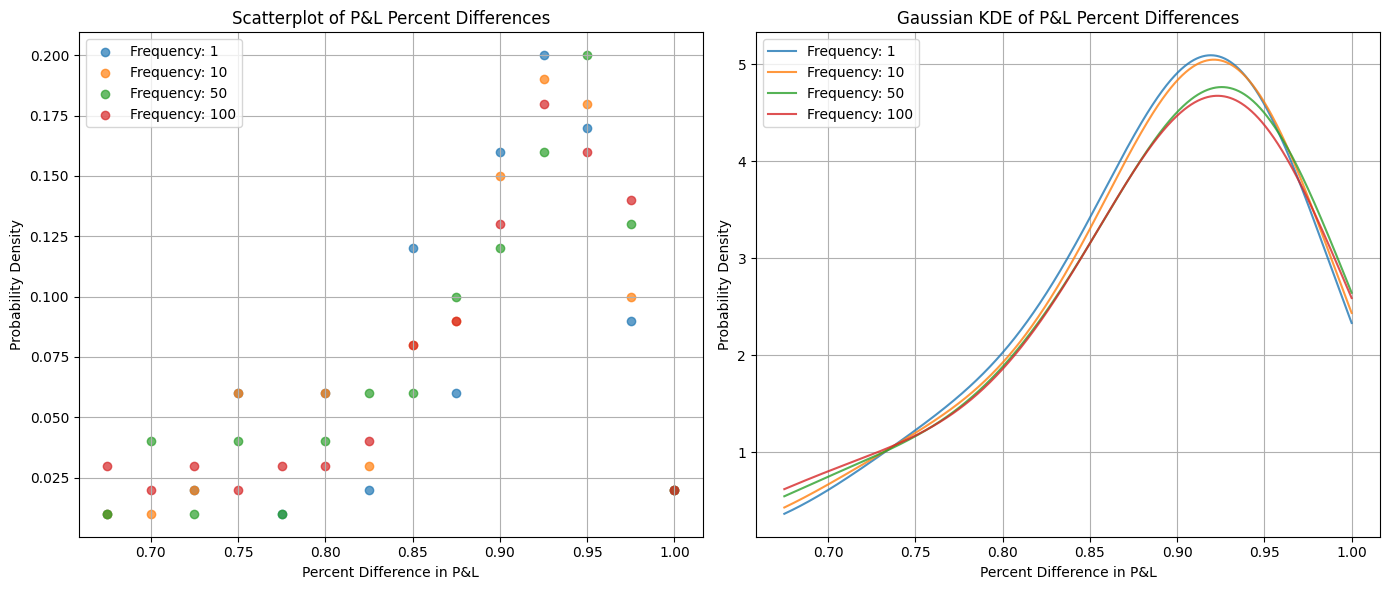

In [ ]:
# Plot the data and report the metrics
plot_histograms(histograms, hedge_freq, simulation_count)

 # GARCH SIMULATION

In [ ]:
# RUNNING WITH GARCH

# Multi-simulation run parameters
simulation_count = 100
hedge_freq = [1, 10, 50, 100]
bucket_size = 0.025

# Create histograms
histograms, metrics = create_pdfs(simulation_count, hedge_freq, bucket_size, True)

Running Simulation 0/100


<ipython-input-36-2d9a3f00d9aa>:2: RuntimeWarning: divide by zero encountered in scalar divide
  d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))


Running Simulation 10/100
Running Simulation 20/100
Running Simulation 30/100
Running Simulation 40/100
Running Simulation 50/100
Running Simulation 60/100
Running Simulation 70/100
Running Simulation 80/100
Running Simulation 90/100
Running Simulation 100/100
Done!

Final Metrics Across Simulations:
Sharpe Ratio:
  - Hedging every 1 steps: 0.0100
  - Hedging every 10 steps: 0.0121
  - Hedging every 50 steps: 0.0213
  - Hedging every 100 steps: 0.0236
P&L Std Dev:
  - Hedging every 1 steps: 2.7492
  - Hedging every 10 steps: 3.5912
  - Hedging every 50 steps: 6.5083
  - Hedging every 100 steps: 7.6901
Hedge MSE:
  - Hedging every 1 steps: 63.8734
  - Hedging every 10 steps: 63.3111
  - Hedging every 50 steps: 60.1608
  - Hedging every 100 steps: 57.7215


Stats for 1 frequency:
  Mode: 0.028
  Mean: 0.039
  Std Dev: 0.118
  Skewness: 0.075
  Kurtosis: -1.112
----------------------------------------
Stats for 10 frequency:
  Mode: 0.031
  Mean: -0.004
  Std Dev: 0.232
  Skewness: -0.192
  Kurtosis: -1.006
----------------------------------------
Stats for 50 frequency:
  Mode: 0.041
  Mean: -0.195
  Std Dev: 0.637
  Skewness: -1.353
  Kurtosis: 1.711
----------------------------------------
Stats for 100 frequency:
  Mode: 0.081
  Mean: -0.238
  Std Dev: 0.761
  Skewness: -1.634
  Kurtosis: 3.051
----------------------------------------


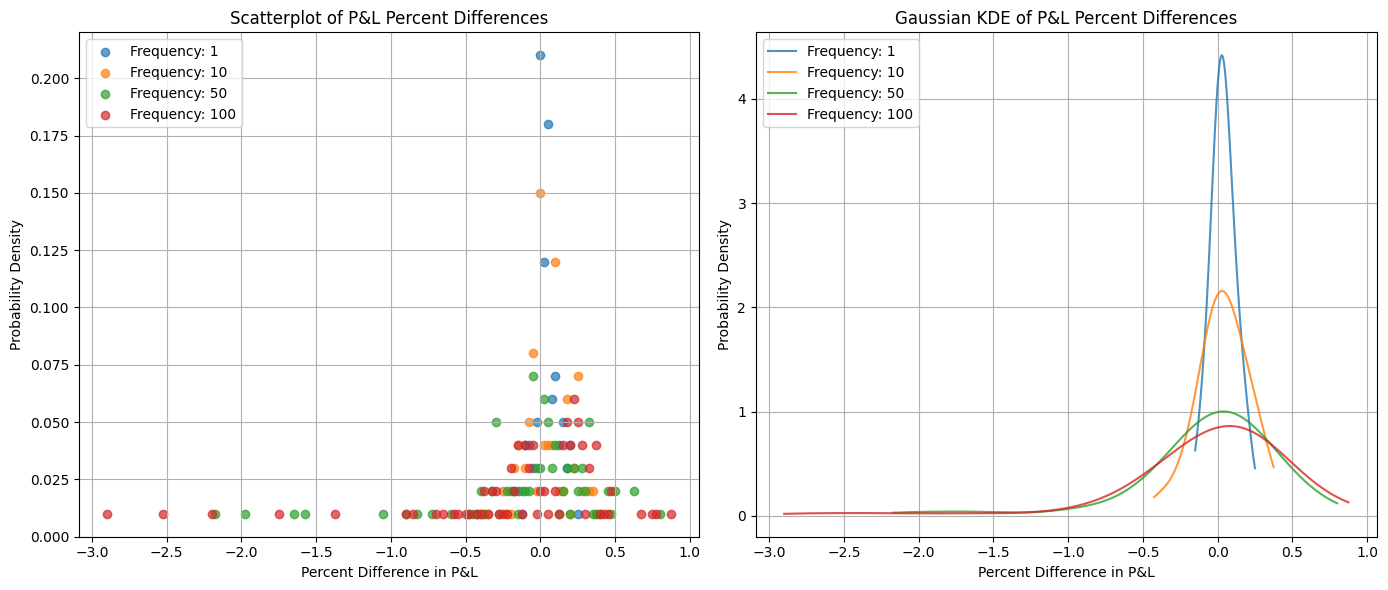

In [ ]:
# Plot the data and report the metrics
plot_histograms(histograms, hedge_freq, simulation_count)

 # Part 8: Using Historical Data